In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.offsetbox import AnchoredText
from scipy import stats
from scipy.stats import median_abs_deviation

In [2]:
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'DejaVu Sans'],
    'figure.titlesize': 16,
    'axes.titlesize': 16,
    'axes.labelsize': 12,

    'axes.titleweight': 'bold',
    'axes.labelweight': 'bold',

    'legend.frameon': False,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.axisbelow': True
})

In [3]:
def format_plot(ax, title, xlabel, ylabel, horizontal=False):

    ax.set_title(title, pad=20)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    if horizontal:
        ax.grid(axis='x', linestyle='--', alpha=0.5)
        ax.grid(axis='y', visible=False)
    else:
        ax.grid(axis='y', linestyle='--', alpha=0.5)
        ax.grid(axis='x', visible=False)

In [4]:
def get_clean_mask(data, threshold=3.5):
    """
    Apply Iglewicz and Hoaglin's robust outlier detection.
    Returns: Boolean mask (True = Valid, False = Outlier)
    """
    median = np.median(data)
    mad = median_abs_deviation(data, scale='normal')
    modified_z_score = 0.6745 * (data - median) / mad
    return modified_z_score.abs() < threshold

def get_limits(data, sigma=3.5, min_floor=0.5, reference_col=None, cv_floor=0.015):
    """
    Calculates a ROBUST SYMMETRIC limit.
    Hybrid Mode: Supports both FIXED floors (e.g., 0.5 kg) and DYNAMIC floors (e.g., 1.5% of TBW).

    Args:
    - data (Series): The error/difference column.
    - sigma (float): Outlier threshold (default 3.5).
    - min_floor (float): The default HARD floor (used if reference_col is None).
    - reference_col (Series, Optional): The magnitude column (e.g., TBW).
      If provided, the floor becomes dynamic (Mean of Ref * cv_floor).
    - cv_floor (float): The percentage noise floor (default 1.5% = 0.015).
    """
    # 1. Clean Data (Drop NaNs)
    clean_data = data.dropna()

    # 2. Calculate Statistical Limit (MAD)
    # This captures the natural spread of your specific dataset
    mad = stats.median_abs_deviation(clean_data, scale=1.4826)
    stat_limit = sigma * mad

    # 3. Determine the Floor Strategy
    if reference_col is not None:
        # [DYNAMIC MODE] Floor = % of the Reference Magnitude
        # Align reference to clean_data indices to avoid size mismatch
        ref_clean = reference_col.loc[clean_data.index]
        floor_val = ref_clean.abs().mean() * cv_floor
    else:
        # [STATIC MODE] Floor = Fixed Number (Backwards Compatible)
        floor_val = min_floor

    # 4. Final Limit: The Greater of the Two
    # Prevents collapse on perfect data, but respects physics on noisy data.
    return max(stat_limit, floor_val)

In [5]:
# --- 1. THE LOW-LEVEL WORKER (Draws one column) ---
def _plot_single_track(data, title, ax_box, ax_hist, unit="kg", target_val=0.0):
    """
    Internal helper: Draws the boxplot and histogram on specific axes.
    """
    # Boxplot (Top)
    sns.boxplot(x=data, ax=ax_box, color='tab:red', width=0.5,
                flierprops={"marker": "x", "markeredgecolor": "firebrick", "markersize": 8})
    ax_box.set_title(f"{title}\nOutlier Detection", fontweight='bold', fontsize=10)
    ax_box.axvline(target_val, color='black', linestyle='--', alpha=0.5)
    ax_box.set_xlabel("")
    ax_box.tick_params(axis='x', labelbottom=False)

    # Histogram (Bottom)
    if not data.isnull().all():
        sns.histplot(x=data, ax=ax_hist, color='#E6B0AA', bins=30, kde=True,
                     line_kws={'linewidth': 2, 'color': 'firebrick'})

        mean_val = data.mean()
        ax_hist.axvline(mean_val, color='black', linestyle='--', label=f'Mean: {mean_val:.2f} {unit}')
        ax_hist.axvline(target_val, color='green', linestyle=':', alpha=0.5, label=f'Target: {target_val} {unit}')
        ax_hist.legend(loc='upper right', fontsize=9)

    ax_hist.set_title("Distribution Shape", fontweight='bold', fontsize=10)
    ax_hist.set_xlabel(f"Residual Error ({unit})")

# --- 2. THE HIGH-LEVEL MANAGER (Takes only tracks) ---
def plot_all_tracks(df, tracks, figure_title="Distribution Analysis"):
    """
    Master function. Handles layout creation and iteration automatically.

    Args:
        df (pd.DataFrame): The source dataframe.
        tracks (list of tuples): List of (Title, Column_Name, Unit).
                                 Example: [('Title A', 'col_a', 'kg'), ...]
        figure_title (str): Global title for the figure.
    """
    n_tracks = len(tracks)

    # Dynamic Layout: Create 2 rows (Box + Hist) and N columns (Tracks)
    fig, axes = plt.subplots(2, n_tracks, figsize=(6 * n_tracks, 10),
                             constrained_layout=True, sharex='col')

    # Handle the edge case where n_tracks=1 (axes is 1D array, needs 2D logic)
    if n_tracks == 1:
        axes = np.array([[axes[0]], [axes[1]]])

    # Iteration Logic
    for i, (title, col_name, unit) in enumerate(tracks):
        # Safety Check: Does column exist?
        if col_name not in df.columns:
            print(f"⚠️ WARNING: Column '{col_name}' not found. Skipping.")
            continue

        _plot_single_track(
            data=df[col_name],
            title=title,
            ax_box=axes[0, i],   # Row 0 = Boxplot
            ax_hist=axes[1, i],  # Row 1 = Histogram
            unit=unit
        )

    plt.suptitle(figure_title, y=1.05, fontsize=18, fontweight='bold')
    plt.show()

In [6]:
def plot_logic_map(df, track_config):
    """
    Plots the 5-State Logic Map using the EXACT logic and styling provided.

    Args:
        df (pd.DataFrame): The source dataframe containing data and masks.
        track_config (dict): A dictionary mapping the generic logic to your specific column names.
    """

    # --- UNPACK CONFIGURATION ---
    # We map generic names to your specific variables to allow swapping tracks
    x_col = track_config['x_col']
    y_col = track_config['y_col']

    lim_x = track_config['lim_x']
    lim_y = track_config['lim_y']
    lim_sum = track_config['lim_sum']

    # Boolean Masks (Series of True/False)
    mask_fit = track_config['mask_fit']
    mask_fail_x = track_config['mask_fail_x']
    mask_fail_y = track_config['mask_fail_y']
    mask_rescue = track_config['mask_rescue']
    mask_fail_all = track_config['mask_fail_all']

    # --- START PLOTTING (Your Original Code) ---
    fig, ax = plt.subplots(figsize=(12, 12), constrained_layout=True)

    # 1. DYNAMIC ZOOM (Context-Aware)
    max_val = max(
        df[x_col].abs().max(),
        df[y_col].abs().max(),
        lim_x,
        lim_y,
        lim_sum,
        40
    ) * 1.15

    # === 2. DRAW SAFETY ZONES (Background) ===

    # A. Diagonal "Rescue" Zone (The Sum Limit)
    diag_x = np.linspace(-max_val * 2, max_val * 2, 100)
    ax.fill_between(diag_x, diag_x - lim_sum, diag_x + lim_sum,
                    color='#E8F5E9', alpha=0.6, zorder=0, label='Sum Logic Zone')

    # B. The "Perfect Box" (Lean & Ratio Limits)
    ax.fill_between([-lim_x, lim_x],
                    -lim_y, lim_y,
                    color='#FFF3E0', alpha=0.5, zorder=1, label='Strict Limits Box')

    # Draw Boundary Lines
    ax.axvline(-lim_x, color='#FF9800', linestyle='--', alpha=0.4)
    ax.axvline(lim_x, color='#FF9800', linestyle='--', alpha=0.4)
    ax.axhline(-lim_y, color='#FF9800', linestyle='--', alpha=0.4)
    ax.axhline(lim_y, color='#FF9800', linestyle='--', alpha=0.4)

    # === 3. PLOT THE 5 LOGIC STATES ===

    def annotate_points(data_subset, color, y_offset=0):
        """Helper to label points with their ID"""
        if len(data_subset) > 0:
            for i, row in data_subset.iterrows():
                ax.text(row[x_col], row[y_col] + y_offset,
                        f"{row.name}",
                        fontsize=8, fontweight='bold', color=color,
                        ha='center', va='bottom', zorder=20)

    # 1. FIT BOTH (Perfect)
    sns.scatterplot(data=df[mask_fit],
                    x=x_col, y=y_col,
                    color='gray', alpha=0.3, s=30, label='Fit (Strict)', ax=ax, zorder=2)

    # 2. FAIL LEAN ONLY (Ratio is Good)
    data_fail_lean = df[mask_fail_x]
    sns.scatterplot(data=data_fail_lean, x=x_col, y=y_col,
                    color='#1E88E5', s=80, marker='v', label='Fail X Only (Lean)', ax=ax, zorder=4)
    annotate_points(data_fail_lean, '#0D47A1', y_offset=max_val*0.02)

    # 3. FAIL RATIO ONLY (Lean is Good)
    data_fail_ratio = df[mask_fail_y]
    sns.scatterplot(data=data_fail_ratio, x=x_col, y=y_col,
                    color='#8E24AA', s=80, marker='<', label='Fail Y Only (Ratio)', ax=ax, zorder=4)
    annotate_points(data_fail_ratio, '#4A148C', y_offset=max_val*0.02)

    # 4. RESCUE (SUM LOGIC)
    data_rescue = df[mask_rescue]
    sns.scatterplot(data=data_rescue, x=x_col, y=y_col,
                    color='#43A047', s=100, marker='P', edgecolor='black', label='Rescue (Sum Logic)', ax=ax, zorder=5)
    annotate_points(data_rescue, '#1B5E20', y_offset=max_val*0.02)

    # 5. FAIL ALL (CRITICAL)
    data_fail_all = df[mask_fail_all]
    sns.scatterplot(data=data_fail_all, x=x_col, y=y_col,
                    color='#D32F2F', s=150, marker='X', edgecolor='white', linewidth=1.5, label='FAIL ALL', ax=ax, zorder=10)
    annotate_points(data_fail_all, '#B71C1C', y_offset=max_val*0.03)


    # === 4. FINAL POLISH ===
    ax.set_aspect('equal')
    ax.set_xlim(-max_val, max_val)
    ax.set_ylim(-max_val, max_val)

    # Dynamic Title
    title_text = track_config.get('title', "5-State Logic Classification Map")
    ax.set_title(title_text, fontweight='bold', fontsize=14)
    ax.set_xlabel(f"Lean Deviation (X) [Limit: ±{lim_x}]")
    ax.set_ylabel(f"Ratio Deviation (Y) [Limit: ±{lim_y}]")

    # Center Crosshairs
    ax.axhline(0, color='black', linewidth=1, alpha=0.8, zorder=3)
    ax.axvline(0, color='black', linewidth=1, alpha=0.8, zorder=3)

    ax.legend(loc='upper left', framealpha=0.95, fontsize='small')
    ax.grid(True, linestyle=':', alpha=0.4)

    plt.show()

In [7]:
def _Bland_Altman_comparison(dataframe, col_mean_raw, col_diff_raw, col_mean_fixed, col_diff_fixed,
                             col_tbw_fix_bool, col_icw_fix_bool, col_ecf_fix_bool, series_valid_mask):

    df = dataframe.copy()

    # 1. Align Masks
    df['__valid__'] = series_valid_mask.fillna(False).astype(bool)

    # 2. Global Limits
    y_all = pd.concat([df[col_diff_raw], df[col_diff_fixed]])
    y_max = y_all.max()
    y_min = y_all.min()
    y_range = y_max - y_min
    y_lims = (y_min - y_range * 0.15, y_max + y_range * 0.15)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8), sharey=True)

    # Colors
    c_valid  = '#95a5a6' # Concrete Grey
    c_red    = '#c0392b' # Dark Red (Fail)
    c_green  = '#27ae60' # Nephritis Green (TBW Fix)
    c_blue   = '#2980b9' # Belize Hole Blue (ICW Fix)
    c_purple = '#8e44ad' # Wisteria Purple (ECF/Ratio Fix)
    c_yellow = '#f1c40f' # Sunflower Yellow (Stat Outlier)

    # Helper for Stats Box
    def add_stats_box(ax, data, loc='lower right'):
        mean = data.mean()
        sd = data.std()
        loa_up = mean + 1.96 * sd
        loa_low = mean - 1.96 * sd
        stats_text = (f"Bias: {mean:.2f}\nSD: {sd:.2f}\nLOA: [{loa_low:.2f}, {loa_up:.2f}]")
        at = AnchoredText(stats_text, prop=dict(size=10, fontfamily='monospace'),
                          frameon=True, loc=loc)
        at.patch.set_boxstyle("round,pad=0.2,rounding_size=0.2")
        at.patch.set_edgecolor('#dcdcdc')
        at.patch.set_alpha(0.95)
        ax.add_artist(at)
        return mean, loa_up, loa_low

    # ==========================================
    # PANEL A: RAW DATA (Physics vs Stats)
    # ==========================================
    mean_a, loa_up_a, loa_low_a = add_stats_box(ax1, df[col_diff_raw])

    mask_stat_outlier = (df[col_diff_raw] > loa_up_a) | (df[col_diff_raw] < loa_low_a)

    # Logic: Red (Fail Logic) > Yellow (Fail Stat) > Gray (Valid)
    cond_red    = ~df['__valid__']
    cond_yellow = df['__valid__'] & mask_stat_outlier

    conditions_a = [cond_red, cond_yellow]
    choices_a    = ['Failed Check', 'Stat Outlier']
    df['Status_A'] = np.select(conditions_a, choices_a, default='Valid')

    # Plot Layering
    palette_a = {'Valid': c_valid, 'Stat Outlier': c_yellow, 'Failed Check': c_red}
    markers_a = {'Valid': 'o',     'Stat Outlier': 'D',      'Failed Check': 'X'}

    ax1.axhspan(loa_low_a, loa_up_a, color=c_valid, alpha=0.1, zorder=0)

    for status in ['Valid', 'Stat Outlier', 'Failed Check']:
        subset = df[df['Status_A'] == status]
        if subset.empty: continue

        alpha = 0.3 if status == 'Valid' else 0.8
        size  = 40  if status == 'Valid' else 60
        edge  = 'white' if status != 'Valid' else None
        z_ord = 1 if status == 'Valid' else (2 if status == 'Stat Outlier' else 3)

        ax1.scatter(subset[col_mean_raw], subset[col_diff_raw], c=palette_a[status], marker=markers_a[status],
                    s=size, alpha=alpha, edgecolors=edge, linewidth=0.5, label=status, zorder=z_ord)

    ax1.axhline(mean_a, color='black', lw=1.5, zorder=4)
    ax1.axhline(loa_up_a, color='black', ls=':', lw=1.2, zorder=4)
    ax1.axhline(loa_low_a, color='black', ls=':', lw=1.2, zorder=4)
    ax1.set_title("A. Raw Data Diagnosis", pad=15)
    ax1.set_xlabel("Mean (Raw + Ref) / 2")
    ax1.set_ylabel("Difference (Method - Ref)")
    ax1.set_ylim(y_lims)
    ax1.legend(loc='upper right')

    # ==========================================
    # PANEL B: REPAIRED DATA (Fix Type)
    # ==========================================
    mean_b, loa_up_b, loa_low_b = add_stats_box(ax2, df[col_diff_fixed])

    # --- STATUS LOGIC ---
    # We use the boolean columns passed directly to categorize the fix

    cond_valid = df['__valid__']
    cond_1   = df[col_tbw_fix_bool].fillna(False).astype(bool)
    cond_2   = df[col_icw_fix_bool].fillna(False).astype(bool)
    cond_3   = df[col_ecf_fix_bool].fillna(False).astype(bool)

    # Priority Order: If it was valid originally -> Gray. Then check specific fixes.
    conditions_b = [
        cond_valid,
        cond_1,
        cond_2,
        cond_3
    ]

    # Labels based on Column Names (cleaned up)
    label_tbw = col_tbw_fix_bool.replace('_status', '').replace('fixed', 'Fixed')
    label_icw = col_icw_fix_bool.replace('_status', '').replace('fixed', 'Fixed')
    label_ecf = col_ecf_fix_bool.replace('_status', '').replace('fixed', 'Fixed')

    choices_b = ['Valid', label_tbw, label_icw, label_ecf]

    # Everything else is Unresolved
    df['Status_B'] = np.select(conditions_b, choices_b, default='Unresolved')

    # Define Palette dynamically
    palette_b = {
        'Valid': c_valid,
        label_tbw: c_green,
        label_icw: c_blue,
        label_ecf: c_purple,
        'Unresolved': c_red
    }

    markers_b = {
        'Valid': 'o',
        label_tbw: 'P',
        label_icw: 's',
        label_ecf: '^',
        'Unresolved': 'X'
    }

    # Shaded Region
    ax2.axhspan(loa_low_b, loa_up_b, color=c_green, alpha=0.05, zorder=0)

    # Plot Loop
    for status in ['Valid', label_tbw, label_icw, label_ecf, 'Unresolved']:
        subset = df[df['Status_B'] == status]
        if subset.empty: continue

        alpha = 0.15 if status == 'Valid' else 0.9
        size  = 40   if status == 'Valid' else 100
        edge  = None if status == 'Valid' else 'white'
        z_ord = 1    if status == 'Valid' else 3

        ax2.scatter(subset[col_mean_fixed], subset[col_diff_fixed],
                    c=palette_b[status], marker=markers_b[status],
                    s=size, alpha=alpha, edgecolors=edge, linewidth=0.5,
                    label=status, zorder=z_ord)

    # Reference Lines
    ax2.axhline(mean_b, color='black', lw=1.5, zorder=2)
    ax2.axhline(loa_up_b, color=c_green, ls='--', lw=1.5, zorder=2)
    ax2.axhline(loa_low_b, color=c_green, ls='--', lw=1.5, zorder=2)

    # --- ANNOTATIONS ---
    df_bad = df[df['Status_B'] == 'Unresolved']

    if not df_bad.empty:
        all_fails = df_bad.reindex(df_bad[col_diff_fixed].abs().sort_values(ascending=False).index)
        for idx, row in all_fails.iterrows():
            ax2.annotate(f"{idx}", (row[col_mean_fixed], row[col_diff_fixed]),
                         xytext=(0, 7), textcoords='offset points', ha='center',
                         fontsize=8, fontweight='bold', color=c_red,
                         bbox=dict(boxstyle="round,pad=0.1", fc="white", alpha=0.6, ec=c_red))

    ax2.set_title("B. Algorithm Performance (Component View)", pad=15)
    ax2.set_xlabel("Mean (Repaired + Ref) / 2")

    # Smart Legend Order
    handles, labels = ax2.get_legend_handles_labels()
    # Ensure specific order of appearance in legend
    target_order = ['Valid', label_tbw, label_icw, label_ecf, 'Unresolved']
    order_idx = [labels.index(l) for l in target_order if l in labels]
    ax2.legend([handles[i] for i in order_idx], [labels[i] for i in order_idx], loc='upper right')

    plt.tight_layout()
    plt.show()

In [8]:
filePath = '../../Storage/Dataset/UCI_Gallstone_Dataset.csv'
df = pd.read_csv(filePath)

In [9]:
df_bioimpedance = df[[
    'Weight',
    'Total Body Water (TBW)',         # Measured in kg
    'Extracellular Water (ECW)',      # Measured in kg
    'Intracellular Water (ICW)',      # Measured in kg
    'Extracellular Fluid/Total Body Water (ECF/TBW)', # Derived Fluid Ratio
    'Total Body Fat Ratio (TBFR) (%)',# Percentage of total mass
    'Lean Mass (LM) (%)',             # Percentage of fat-free mass
    'Body Protein Content (Protein) (%)', # Protein composition percentage
    'Visceral Fat Rating (VFR)',      # Corresponds to "Visceral Adiposity Index" in text [cite: 61]
    'Bone Mass (BM)',                 # Measured in kg
    'Muscle Mass (MM)',               # Measured in kg
    'Obesity (%)',                    # Degree of obesity percentage
    'Total Fat Content (TFC)',        # Measured in kg
    'Visceral Fat Area (VFA)',        # Measured in kg
    'Visceral Muscle Area (VMA) (Kg)' # Measured in kg
]].copy()

In [10]:
# Track A: Physics (Summation) | TBW - (ECW + ICW)
col_TBW_calc_sum = 'TBW_calc_sum'
df_bioimpedance[col_TBW_calc_sum] = df_bioimpedance['Extracellular Water (ECW)'] + df_bioimpedance['Intracellular Water (ICW)']

col_TBW_disc_sum = 'TBW_disc_sum'
df_bioimpedance[col_TBW_disc_sum] = df_bioimpedance['Total Body Water (TBW)'] - df_bioimpedance[col_TBW_calc_sum]

# Track B: Logic (Ratio) | TBW - ECW / (Ratio/100)
col_TBW_calc_ratio = 'TBW_calc_ratio'
df_bioimpedance[col_TBW_calc_ratio] = df_bioimpedance['Extracellular Water (ECW)'] / (df_bioimpedance['Extracellular Fluid/Total Body Water (ECF/TBW)'] / 100)

col_TBW_disc_ratio = 'TBW_disc_ratio'
df_bioimpedance[col_TBW_disc_ratio] = df_bioimpedance['Total Body Water (TBW)'] - df_bioimpedance[col_TBW_calc_ratio]

col_TBW_calc_sumOfCalc = 'TBW_calc_sumOfRatio'
df_bioimpedance[col_TBW_calc_sumOfCalc] = df_bioimpedance['Extracellular Fluid/Total Body Water (ECF/TBW)'] + df_bioimpedance['Intracellular Water (ICW)'] / df_bioimpedance['Total Body Water (TBW)'] * 100

col_TBW_disc_sumOfCalc = 'TBW_disc_sumOfCalc'
df_bioimpedance[col_TBW_disc_sumOfCalc] = df_bioimpedance[col_TBW_calc_sum] - df_bioimpedance[col_TBW_calc_ratio]

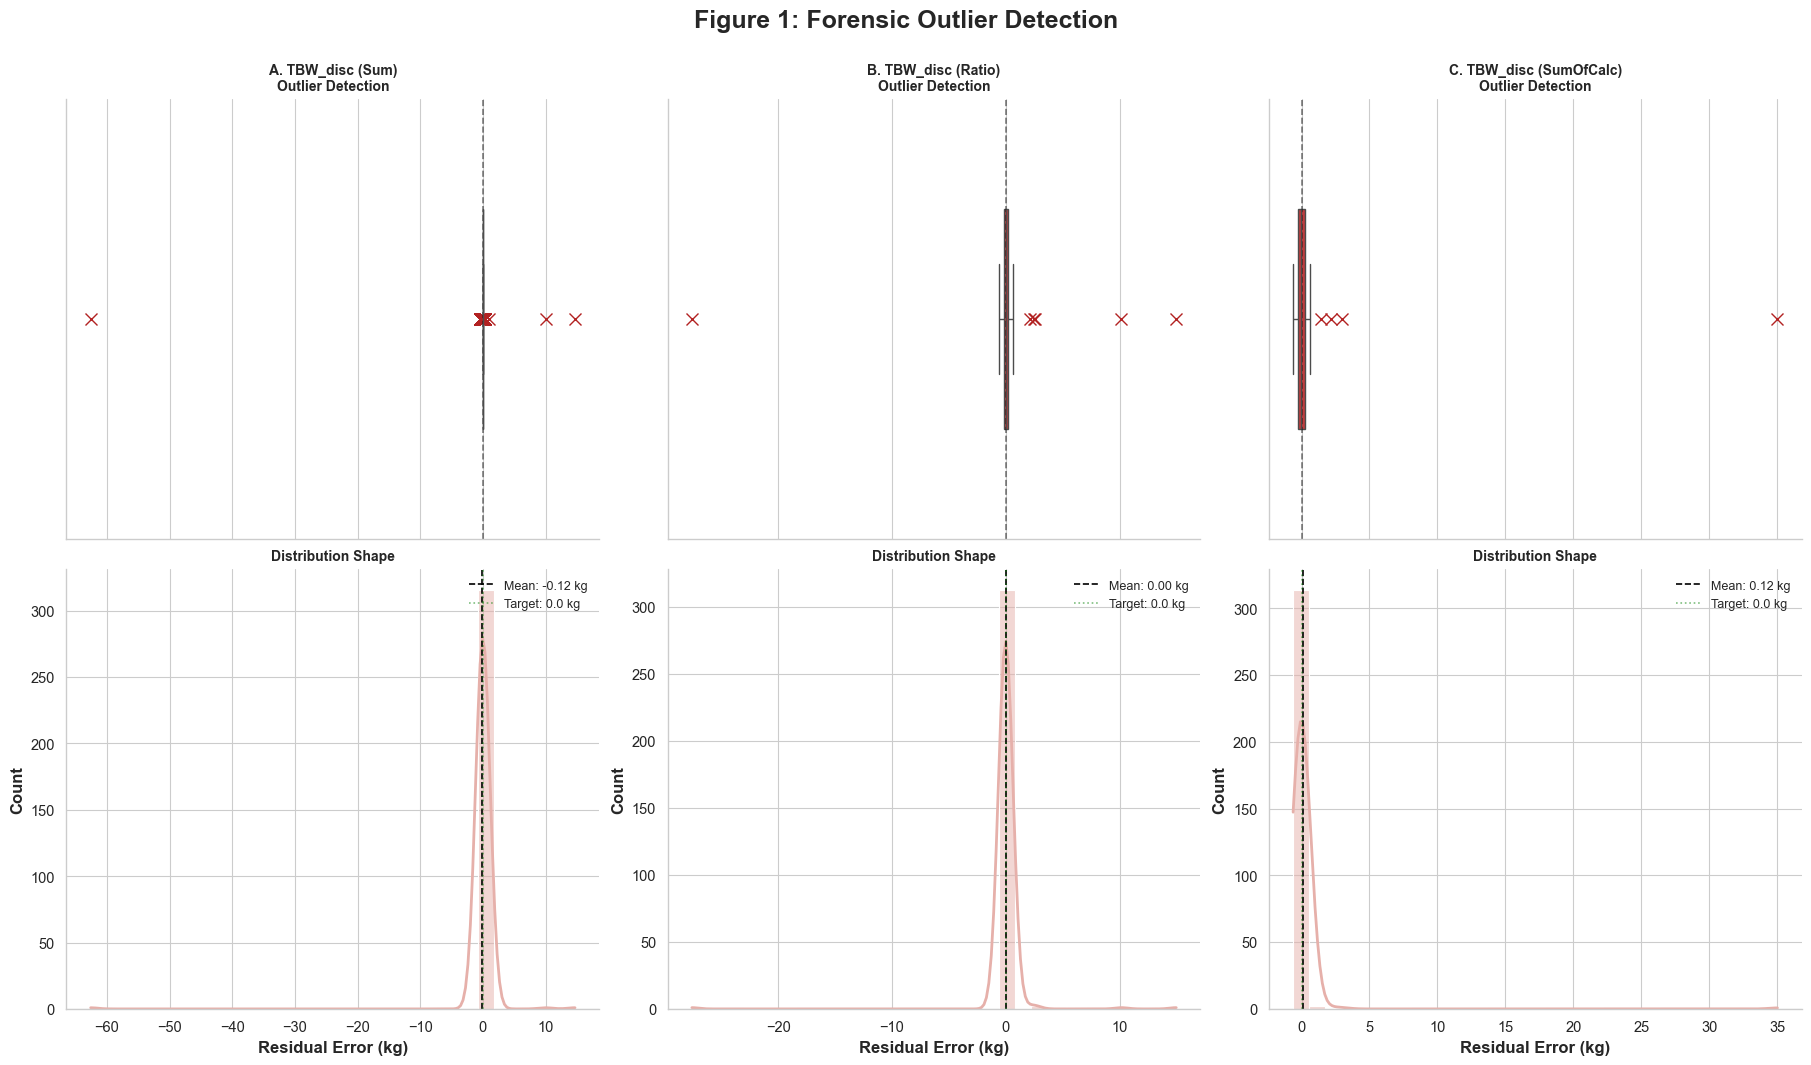

In [11]:
# --- CONFIGURATION ---
my_tracks = [
    ('A. TBW_disc (Sum)',    col_TBW_disc_sum,       'kg'),
    ('B. TBW_disc (Ratio)',   col_TBW_disc_ratio,      'kg'),
    ('C. TBW_disc (SumOfCalc)', col_TBW_disc_sumOfCalc, 'kg')
]

plot_all_tracks(df_bioimpedance, my_tracks, figure_title="Figure 1: Forensic Outlier Detection")

In [12]:
TBW_disc_sum_lim_val = get_limits(df_bioimpedance[col_TBW_disc_sum],reference_col=df_bioimpedance['Total Body Water (TBW)'])

TBW_disc_ratio_lim_val = get_limits(df_bioimpedance[col_TBW_disc_ratio],reference_col=df_bioimpedance['Total Body Water (TBW)'])
TBW_disc_sumOfCalc_lim_val = get_limits(df_bioimpedance[col_TBW_disc_sumOfCalc], reference_col=df_bioimpedance['Extracellular Water (ECW)'])


# 2. GENERATE MASKS (Using the new symmetric limits)
TBW_disc_fit_sum_lim = (df_bioimpedance[col_TBW_disc_sum].abs() < TBW_disc_sum_lim_val)
TBW_disc_fit_ratio_lim = (df_bioimpedance[col_TBW_disc_ratio].abs() < TBW_disc_ratio_lim_val)
TBW_disc_fit_sumOfCalc_lim = (df_bioimpedance[col_TBW_disc_sumOfCalc].abs() < TBW_disc_sumOfCalc_lim_val)

TBW_disc_fit_both_lim       =  TBW_disc_fit_sum_lim &  TBW_disc_fit_ratio_lim
TBW_disc_fail_ratio_lim     =  TBW_disc_fit_sum_lim & ~TBW_disc_fit_ratio_lim
TBW_disc_fail_sum_lim       = ~TBW_disc_fit_sum_lim &  TBW_disc_fit_ratio_lim
TBW_disc_fit_sumOfCalc_lim  = ~TBW_disc_fit_sum_lim & ~TBW_disc_fit_ratio_lim &  TBW_disc_fit_sumOfCalc_lim
TBW_disc_fail_all_lim       = ~TBW_disc_fit_sum_lim & ~TBW_disc_fit_ratio_lim & ~TBW_disc_fit_sumOfCalc_lim

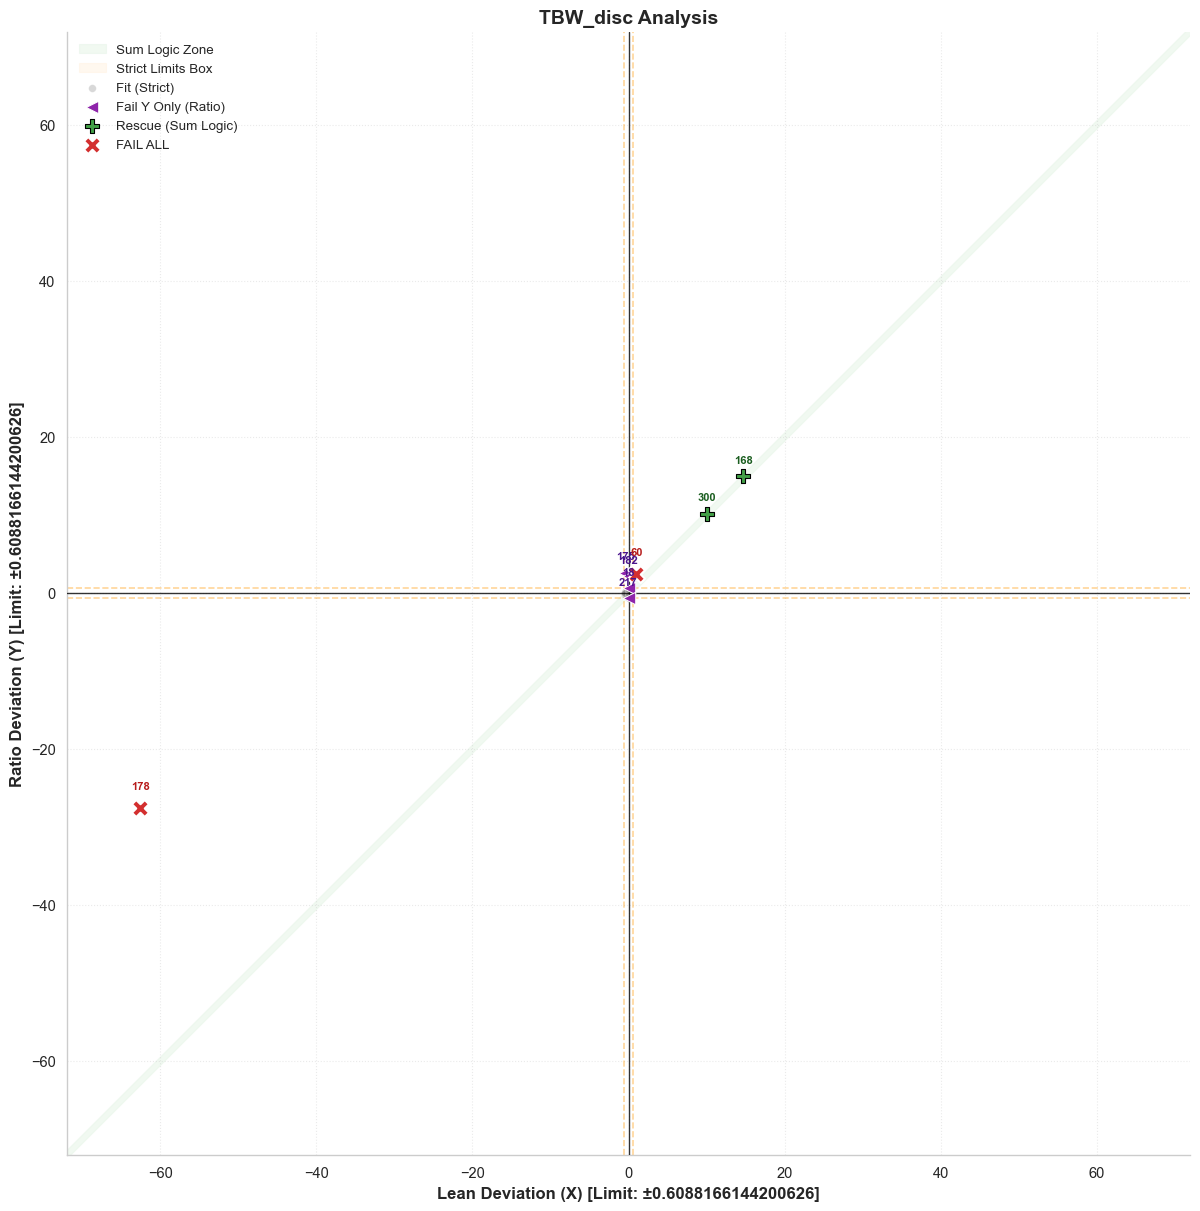

In [13]:
# --- 1. DEFINE YOUR TRACK CONFIGURATION ---
current_track = {
    'title': "TBW_disc Analysis",

    # Columns
    'x_col': col_TBW_disc_sum,
    'y_col': col_TBW_disc_ratio,

    # Limits (Values)
    'lim_x': TBW_disc_sum_lim_val,
    'lim_y': TBW_disc_ratio_lim_val,
    'lim_sum': TBW_disc_sumOfCalc_lim_val,

    # Masks (Boolean Series)
    'mask_fit': TBW_disc_fit_both_lim,
    'mask_fail_x': TBW_disc_fail_sum_lim,
    'mask_fail_y': TBW_disc_fail_ratio_lim,
    'mask_rescue': TBW_disc_fit_sumOfCalc_lim,
    'mask_fail_all': TBW_disc_fail_all_lim
}

# --- 2. EXECUTE ---
plot_logic_map(df_bioimpedance, current_track)

In [14]:
# Fixing TBW column
col_ICW_fixed = 'ICW_fixed'
df_bioimpedance[col_ICW_fixed] = df_bioimpedance['Intracellular Water (ICW)']
col_ICW_fix_status = 'ICW_fixed_status'
df_bioimpedance[col_ICW_fix_status] = False

col_ECF_TBW_fixed = 'ECF/TBW_fixed'
df_bioimpedance[col_ECF_TBW_fixed] = df_bioimpedance['Extracellular Fluid/Total Body Water (ECF/TBW)']
col_ECF_TBW_fix_status = 'ECF/TBW_fixed_status'
df_bioimpedance[col_ECF_TBW_fix_status] = False

col_TBW_fixed = 'TBW_fixed'
df_bioimpedance[col_TBW_fixed] = df_bioimpedance['Total Body Water (TBW)']
col_TBW_fix_status = 'TBW_fixed_status'
df_bioimpedance[col_TBW_fix_status] = False

# CASE 1: Ratio Failed, sum correct -> Assume ICW, ECW and TBW are correct, ECF/TBW is wrong
col_ECF_TBW_calc_ratio = 'ECF/TBW_calc_ratio'
df_bioimpedance[col_ECF_TBW_calc_ratio] = df_bioimpedance['Extracellular Water (ECW)']/df_bioimpedance['Total Body Water (TBW)']*100
df_bioimpedance.loc[TBW_disc_fail_ratio_lim, col_ECF_TBW_fixed] = df_bioimpedance.loc[TBW_disc_fail_ratio_lim, col_ECF_TBW_calc_ratio]
df_bioimpedance.loc[TBW_disc_fail_ratio_lim, col_ECF_TBW_fix_status] = True

# CASE 2: Sum Failed, ratio correct -> Assume ECF/TBW, ECW and TBW are correct, ICW is wrong
col_ICW_calc_sum = 'ICW_calc_sum'
df_bioimpedance[col_ICW_calc_sum] = df_bioimpedance['Total Body Water (TBW)'] - df_bioimpedance['Extracellular Water (ECW)']
df_bioimpedance.loc[TBW_disc_fail_sum_lim, col_ICW_fixed] = df_bioimpedance.loc[TBW_disc_fail_sum_lim, col_ICW_calc_sum]
df_bioimpedance.loc[TBW_disc_fail_sum_lim, col_ICW_fix_status] = True

# CASE 3: Both Failed but sum of ratio near 100% -> Assume ECF/TBW, ECW and ICW are correct, TBW is wrong
df_bioimpedance.loc[TBW_disc_fit_sumOfCalc_lim, col_TBW_fixed] = df_bioimpedance.loc[TBW_disc_fit_sumOfCalc_lim, col_TBW_calc_ratio]
df_bioimpedance.loc[TBW_disc_fit_sumOfCalc_lim, col_TBW_fix_status] = True

In [15]:
# Track C: 4-Component Algorithm | TBW - (Weight - Fat - Bone - Protein - 0.013*Weight)
epsilon_4C = df_bioimpedance['Weight']*0.013

col_TFC_calc_ratio = 'TFC_calc_ratio'
df_bioimpedance[col_TFC_calc_ratio] = (df_bioimpedance['Weight'] * (df_bioimpedance['Total Body Fat Ratio (TBFR) (%)'] / 100))

col_TPC_calc_ratio = 'TPC_calc_ratio'
df_bioimpedance[col_TPC_calc_ratio] = (df_bioimpedance['Weight'] * (df_bioimpedance['Body Protein Content (Protein) (%)'] / 100))

col_TBW_calc_4C = 'TBW_calc_4C'
df_bioimpedance[col_TBW_calc_4C] = df_bioimpedance['Weight'] - df_bioimpedance[col_TFC_calc_ratio] - df_bioimpedance['Bone Mass (BM)'] - df_bioimpedance[
    col_TPC_calc_ratio] - epsilon_4C

col_TBW_disc_4C = 'TBW_disc_4C'
df_bioimpedance[col_TBW_disc_4C] = df_bioimpedance['Total Body Water (TBW)'] - df_bioimpedance[col_TBW_calc_4C]

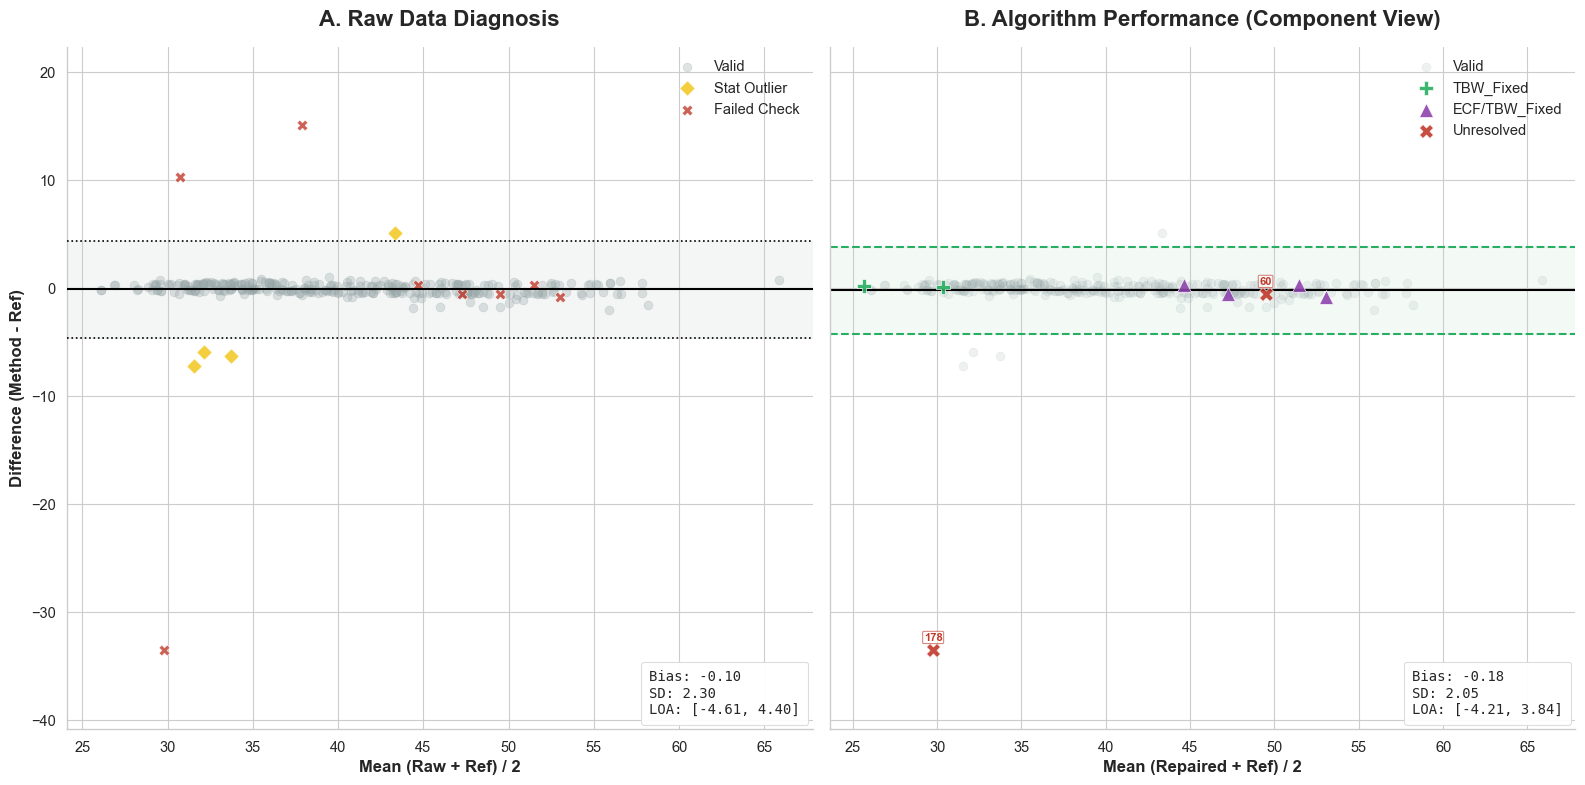

In [16]:
col_TBW_mean_raw = 'TBW_mean_raw'
df_bioimpedance[col_TBW_mean_raw] = (df_bioimpedance['Total Body Water (TBW)'] + df_bioimpedance[col_TBW_calc_4C]) / 2
col_TBW_diff_raw = 'TBW_diff_raw'
df_bioimpedance[col_TBW_diff_raw] = df_bioimpedance['Total Body Water (TBW)'] - df_bioimpedance[col_TBW_calc_4C]
col_TBW_mean_fixed = 'TBW_mean_fixed'
df_bioimpedance[col_TBW_mean_fixed] = (df_bioimpedance[col_TBW_fixed] + df_bioimpedance[col_TBW_calc_4C]) / 2
col_TBW_diff_fixed = 'TBW_diff_fixed'
df_bioimpedance[col_TBW_diff_fixed] = df_bioimpedance[col_TBW_fixed] - df_bioimpedance[col_TBW_calc_4C]

_Bland_Altman_comparison(
    df_bioimpedance,
    col_TBW_mean_raw,
    col_TBW_diff_raw,
    col_TBW_mean_fixed,
    col_TBW_diff_fixed,
    col_TBW_fix_status,
    col_ICW_fix_status,
    col_ECF_TBW_fix_status,
    TBW_disc_fit_both_lim
)

In [17]:
"""
    For those case fail all, there are two way to find TBW, assume the lower residual compare to 4C is more likely to be correct
"""
TBW_diff_4C_ratio = (df_bioimpedance[col_TBW_calc_4C] - df_bioimpedance[col_TBW_calc_ratio]).abs()
TBW_diff_4C_sum = (df_bioimpedance[col_TBW_calc_4C] - df_bioimpedance[col_TBW_calc_sum]).abs()

TBW_ratio_approach = TBW_disc_fail_all_lim & (TBW_diff_4C_ratio < TBW_diff_4C_sum) & TBW_diff_4C_ratio
TBW_sum_approach = TBW_disc_fail_all_lim & (TBW_diff_4C_sum < TBW_diff_4C_ratio) & TBW_diff_4C_sum

# Assume ECF/TBW and ECW is approximately correct, TBW and ICW is wrong
df_bioimpedance.loc[TBW_ratio_approach, col_TBW_fixed] = df_bioimpedance.loc[TBW_ratio_approach, col_TBW_calc_ratio]
df_bioimpedance.loc[TBW_ratio_approach, col_TBW_fix_status] = True
col_ICW_calc_fixedSum = 'ICW_calc_fixedSum'
df_bioimpedance[col_ICW_calc_fixedSum] = df_bioimpedance[col_TBW_calc_ratio] - df_bioimpedance['Extracellular Water (ECW)']
df_bioimpedance.loc[TBW_ratio_approach, col_ICW_fixed] = df_bioimpedance.loc[TBW_ratio_approach, col_ICW_calc_fixedSum]
df_bioimpedance.loc[TBW_ratio_approach, col_ICW_fix_status] = True

# Assume ECW and ICW is approximately correct, TBW and ECF/TBW is wrong
df_bioimpedance.loc[TBW_sum_approach, col_TBW_fixed] = df_bioimpedance.loc[TBW_sum_approach, col_TBW_calc_sum]
df_bioimpedance.loc[TBW_sum_approach, col_TBW_fix_status] = True
col_ECF_TBW_calc_fixedRatio = 'ECF/TBW_calc_fixedRatio'
df_bioimpedance[col_ECF_TBW_calc_fixedRatio] = df_bioimpedance['Extracellular Water (ECW)']*100/df_bioimpedance[col_TBW_calc_ratio]
df_bioimpedance.loc[TBW_sum_approach, col_ECF_TBW_fixed] = df_bioimpedance.loc[TBW_sum_approach, col_ECF_TBW_calc_fixedRatio]
df_bioimpedance.loc[TBW_sum_approach, col_ECF_TBW_fix_status] = True
df_bioimpedance[col_ECF_TBW_calc_fixedRatio]

0      40.00
1      45.00
2      43.00
3      41.00
4      39.00
       ...  
314    42.01
315    42.00
316    43.00
317    40.00
318    45.00
Name: ECF/TBW_calc_fixedRatio, Length: 319, dtype: float64

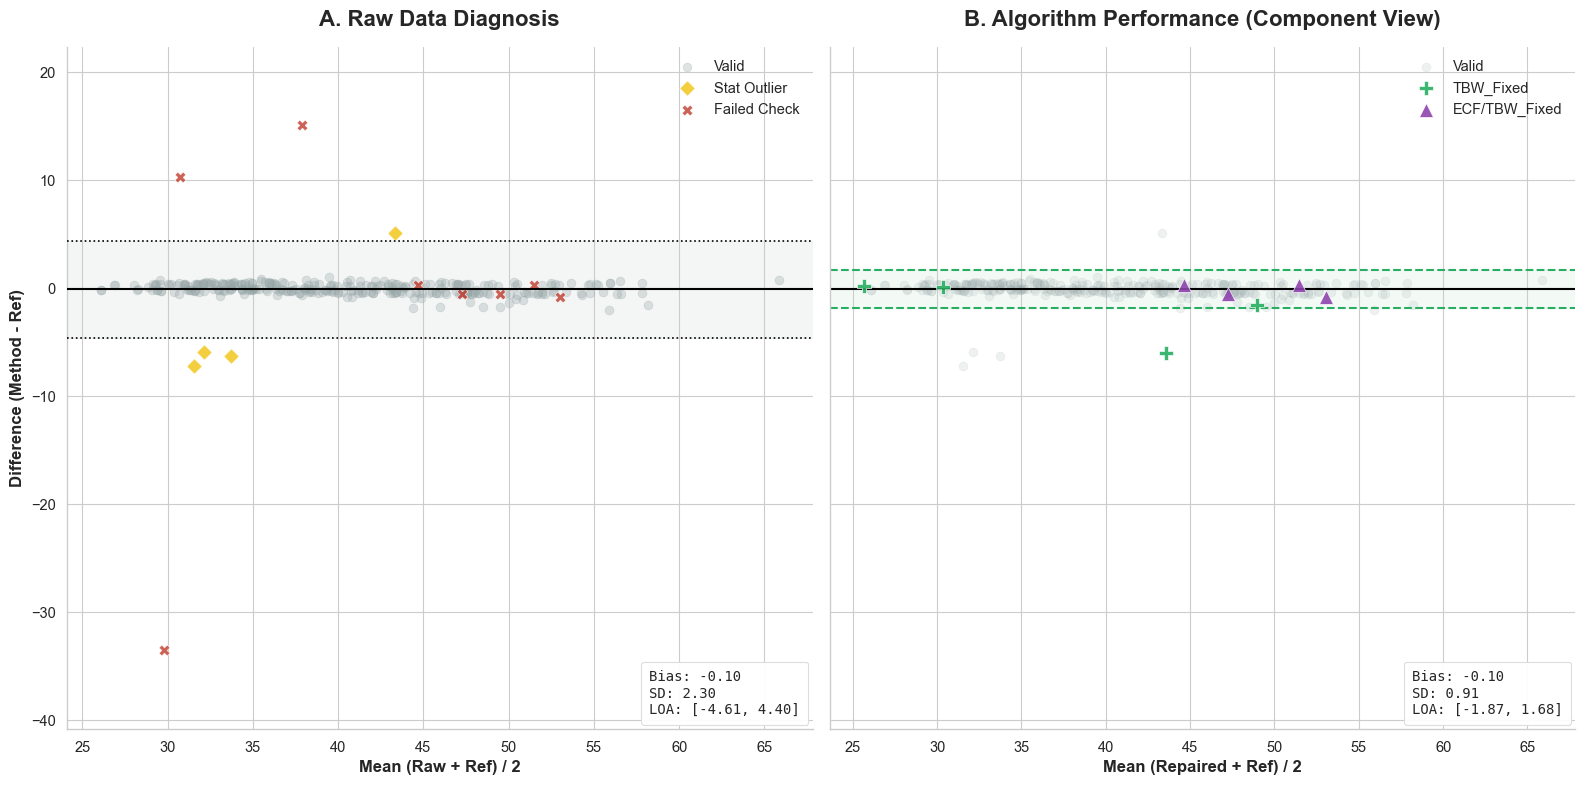

In [18]:
col_TBW_mean_raw = 'TBW_mean_raw'
df_bioimpedance[col_TBW_mean_raw] = (df_bioimpedance['Total Body Water (TBW)'] + df_bioimpedance[col_TBW_calc_4C]) / 2
col_TBW_diff_raw = 'TBW_diff_raw'
df_bioimpedance[col_TBW_diff_raw] = df_bioimpedance['Total Body Water (TBW)'] - df_bioimpedance[col_TBW_calc_4C]
col_TBW_mean_fixed = 'TBW_mean_fixed'
df_bioimpedance[col_TBW_mean_fixed] = (df_bioimpedance[col_TBW_fixed] + df_bioimpedance[col_TBW_calc_4C]) / 2
col_TBW_diff_fixed = 'TBW_diff_fixed'
df_bioimpedance[col_TBW_diff_fixed] = df_bioimpedance[col_TBW_fixed] - df_bioimpedance[col_TBW_calc_4C]

_Bland_Altman_comparison(
    df_bioimpedance,
    col_TBW_mean_raw,
    col_TBW_diff_raw,
    col_TBW_mean_fixed,
    col_TBW_diff_fixed,
    col_TBW_fix_status,
    col_ICW_fix_status,
    col_ECF_TBW_fix_status,
    TBW_disc_fit_both_lim
)

In [19]:
col_TFC_calc_lean = 'TFC_calc_lean'
df_bioimpedance[col_TFC_calc_lean] = df_bioimpedance['Weight'] - (df_bioimpedance['Weight'] * df_bioimpedance['Lean Mass (LM) (%)'] / 100)

col_TFC_disc_lean = 'TFC_disc_lean'
df_bioimpedance[col_TFC_disc_lean] = df_bioimpedance['Total Fat Content (TFC)'] - df_bioimpedance[col_TFC_calc_lean]

col_TFC_calc_ratio = 'TFC_calc_ratio'
df_bioimpedance[col_TFC_calc_ratio] = (df_bioimpedance['Weight'] * (df_bioimpedance['Total Body Fat Ratio (TBFR) (%)'] / 100))

col_TFC_disc_ratio = 'TFC_disc_ratio'
df_bioimpedance[col_TFC_disc_ratio] = df_bioimpedance['Total Fat Content (TFC)'] - df_bioimpedance[col_TFC_calc_ratio]

col_TFC_calc_sumOfRatio = 'TFC_calc_sumOfRatio'
df_bioimpedance[col_TFC_calc_sumOfRatio] = df_bioimpedance['Lean Mass (LM) (%)'] + df_bioimpedance['Total Body Fat Ratio (TBFR) (%)']

col_TFC_disc_sumOfRatio = 'TFC_disc_sumOfRatio'
df_bioimpedance[col_TFC_disc_sumOfRatio] = 100 - df_bioimpedance[col_TFC_calc_sumOfRatio]

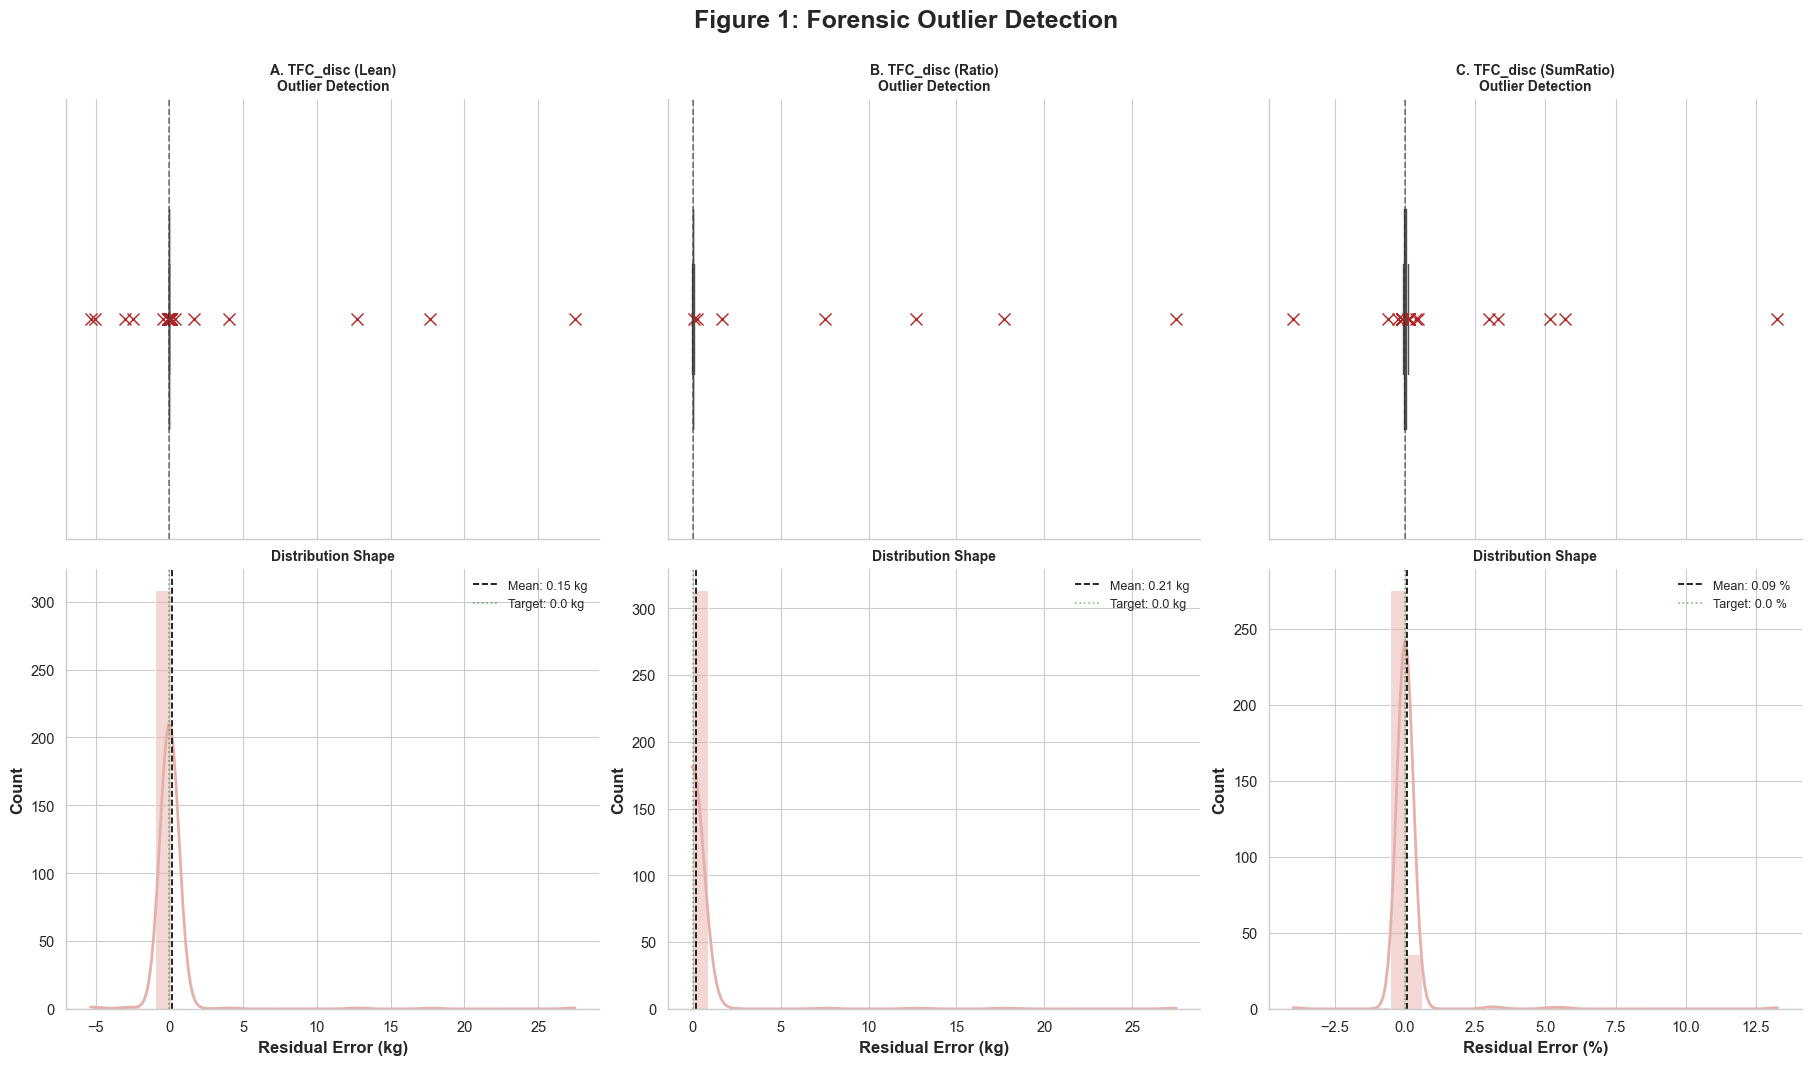

In [20]:
# --- CONFIGURATION ---
my_tracks = [
    ('A. TFC_disc (Lean)',    col_TFC_disc_lean,       'kg'),
    ('B. TFC_disc (Ratio)',   col_TFC_disc_ratio,      'kg'),
    ('C. TFC_disc (SumRatio)',col_TFC_disc_sumOfRatio, '%')
]

plot_all_tracks(df_bioimpedance, my_tracks, figure_title="Figure 1: Forensic Outlier Detection")

In [21]:
TFC_disc_lean_lim_val = get_limits(df_bioimpedance[col_TFC_disc_lean],reference_col=df_bioimpedance['Total Fat Content (TFC)'])
TFC_disc_ratio_lim_val = get_limits(df_bioimpedance[col_TFC_disc_ratio],reference_col=df_bioimpedance['Total Fat Content (TFC)'])
TFC_disc_sumOfRatio_lim_val = 1

# 2. GENERATE MASKS (Using the new symmetric limits)
TFC_disc_fit_lean_lim   = (df_bioimpedance[col_TFC_disc_lean].abs() < TFC_disc_lean_lim_val)
TFC_disc_fit_ratio_lim  = (df_bioimpedance[col_TFC_disc_ratio].abs() < TFC_disc_ratio_lim_val)
TFC_disc_sumOfRatio_lim = (df_bioimpedance[col_TFC_disc_sumOfRatio].abs() < TFC_disc_sumOfRatio_lim_val)

TFC_disc_fit_both_lim       =  TFC_disc_fit_lean_lim &  TFC_disc_fit_ratio_lim
TFC_disc_fail_lean_lim      = ~TFC_disc_fit_lean_lim &  TFC_disc_fit_ratio_lim
TFC_disc_fail_ratio_lim     =  TFC_disc_fit_lean_lim & ~TFC_disc_fit_ratio_lim
TFC_disc_fit_sumOfRatio_lim = ~TFC_disc_fit_lean_lim & ~TFC_disc_fit_ratio_lim &  TFC_disc_sumOfRatio_lim
TFC_disc_fail_all_lim       = ~TFC_disc_fit_lean_lim & ~TFC_disc_fit_ratio_lim & ~TFC_disc_sumOfRatio_lim

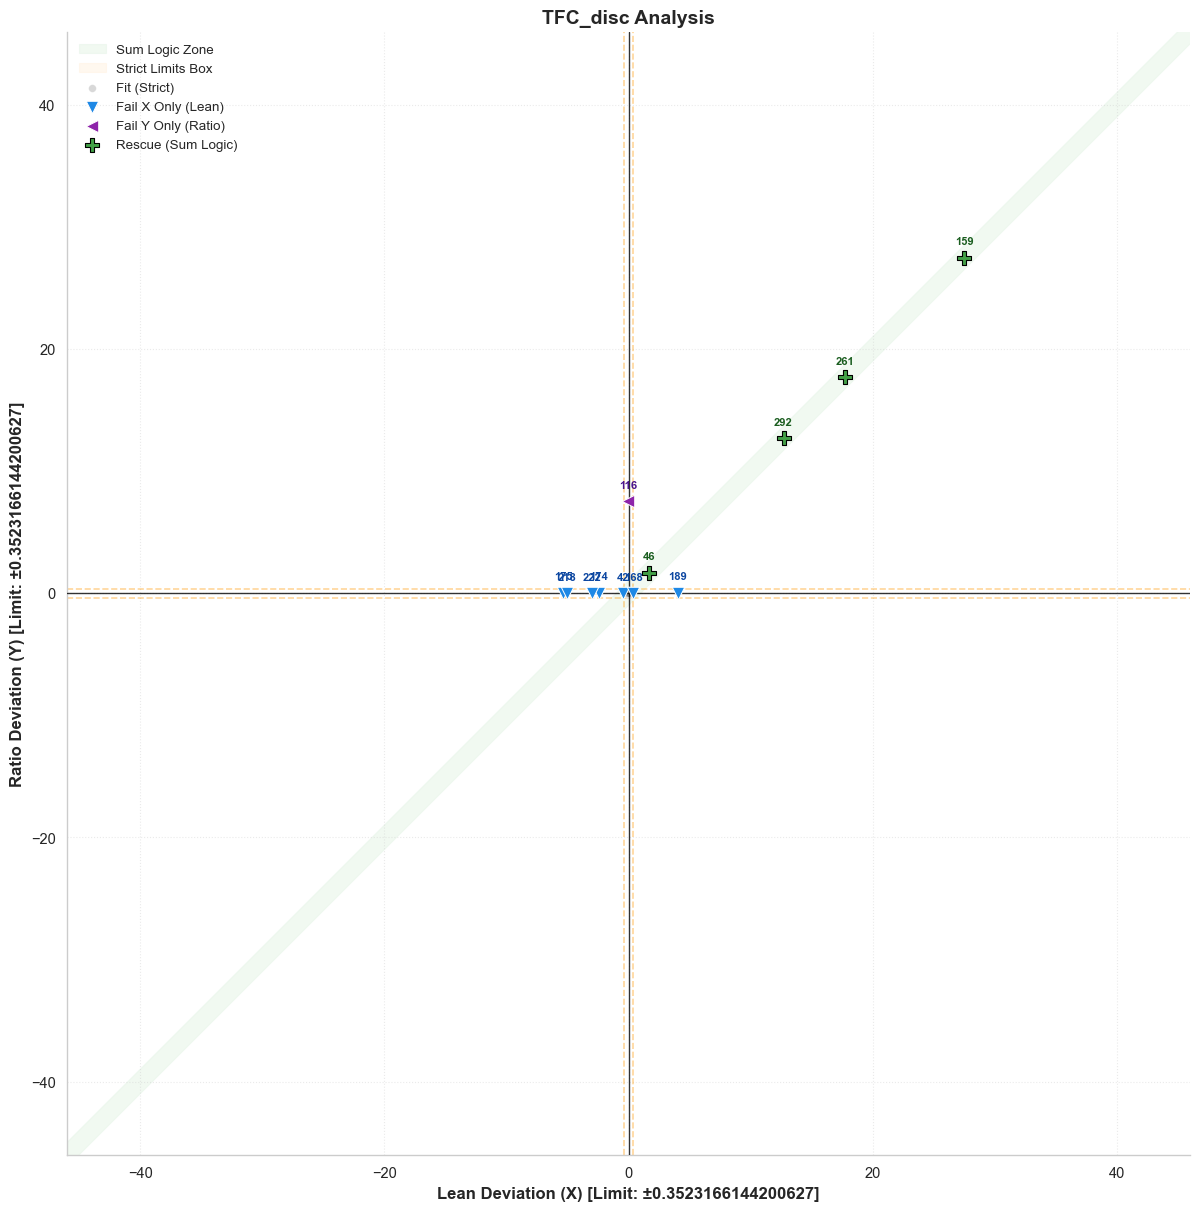

In [22]:
# --- 1. DEFINE YOUR TRACK CONFIGURATION ---
current_track = {
    'title': "TFC_disc Analysis",

    # Columns
    'x_col': col_TFC_disc_lean,           # Your X data column
    'y_col': col_TFC_disc_ratio,          # Your Y data column

    # Limits (Values)
    'lim_x': TFC_disc_lean_lim_val,       # e.g. 2.5
    'lim_y': TFC_disc_ratio_lim_val,      # e.g. 3.0
    'lim_sum': TFC_disc_sumOfRatio_lim_val, # e.g. 4.0

    # Masks (Boolean Series)
    'mask_fit': TFC_disc_fit_both_lim,
    'mask_fail_x': TFC_disc_fail_lean_lim,
    'mask_fail_y': TFC_disc_fail_ratio_lim,
    'mask_rescue': TFC_disc_fit_sumOfRatio_lim,
    'mask_fail_all': TFC_disc_fail_all_lim
}

# --- 2. EXECUTE ---
plot_logic_map(df_bioimpedance, current_track)

In [23]:
# Fixing TFC column
col_TFC_fixed = 'TFC_fixed'
df_bioimpedance[col_TFC_fixed] = df_bioimpedance['Total Fat Content (TFC)']
col_TFC_fix_status = 'TFC_fixed_status'
df_bioimpedance[col_TFC_fix_status] = False

col_TBFR_fixed = 'TBFR_fixed'
df_bioimpedance[col_TBFR_fixed] = df_bioimpedance['Total Body Fat Ratio (TBFR) (%)']
col_TBFR_fix_status = 'TBFR_fixed_status'
df_bioimpedance[col_TBFR_fix_status] = False

col_LM_fixed = 'LM_fixed'
df_bioimpedance[col_LM_fixed] = df_bioimpedance['Lean Mass (LM) (%)']
col_LM_fix_status = 'LM_fixed_status'
df_bioimpedance[col_LM_fix_status] = False


col_LM_calc_sum = 'LM_calc_sum'
df_bioimpedance[col_LM_calc_sum] = 100 - df_bioimpedance['Total Body Fat Ratio (TBFR) (%)']
df_bioimpedance.loc[TFC_disc_fail_lean_lim, col_LM_fixed] = df_bioimpedance.loc[TFC_disc_fail_lean_lim,col_LM_calc_sum]
df_bioimpedance.loc[TFC_disc_fail_lean_lim, col_LM_fix_status] = True

col_TBFR_calc_ratio = 'TBFR_calc_ratio'
df_bioimpedance[col_TBFR_calc_ratio] = df_bioimpedance['Total Fat Content (TFC)'] * 100 /df_bioimpedance['Weight']
df_bioimpedance.loc[TFC_disc_fail_ratio_lim, col_TBFR_fixed] = df_bioimpedance.loc[TFC_disc_fail_ratio_lim,col_TBFR_calc_ratio]
df_bioimpedance.loc[TFC_disc_fail_ratio_lim, col_TBFR_fix_status] = True

df_bioimpedance.loc[TFC_disc_fit_sumOfRatio_lim, col_TFC_fixed] = df_bioimpedance.loc[TFC_disc_fit_sumOfRatio_lim,col_TFC_calc_ratio]
df_bioimpedance.loc[TFC_disc_fit_sumOfRatio_lim, col_TFC_fix_status] = True

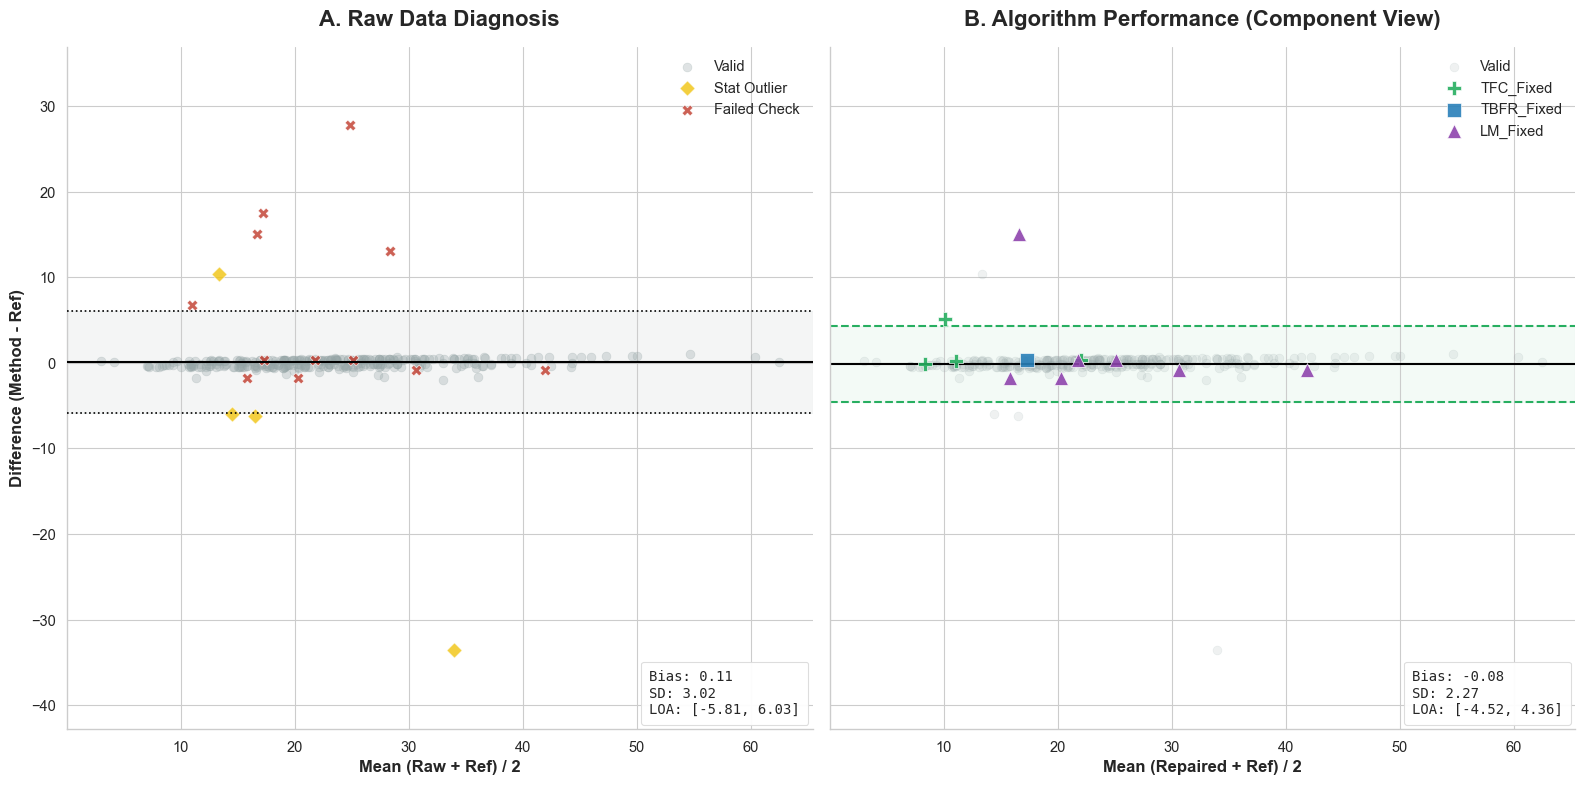

In [24]:
col_TFC_calc_4C_TBW_unfixed = 'TFC_calc_4C_TBW_unfixed'
df_bioimpedance[col_TFC_calc_4C_TBW_unfixed] = df_bioimpedance['Weight'] - df_bioimpedance['Total Body Water (TBW)'] - df_bioimpedance['Bone Mass (BM)'] - df_bioimpedance[col_TPC_calc_ratio] - epsilon_4C

col_TFC_mean_raw_TBW_unfixed = 'TFC_mean_raw_TBW_unfixed'
df_bioimpedance[col_TFC_mean_raw_TBW_unfixed] = (df_bioimpedance['Total Fat Content (TFC)'] + df_bioimpedance[col_TFC_calc_4C_TBW_unfixed]) / 2

col_TFC_diff_raw_TBW_unfixed = 'TFC_diff_raw_TBW_unfixed'
df_bioimpedance[col_TFC_diff_raw_TBW_unfixed] = df_bioimpedance['Total Fat Content (TFC)'] - df_bioimpedance[col_TFC_calc_4C_TBW_unfixed]

col_TFC_mean_fixed_TBW_unfixed = 'TFC_mean_fixed_TBW_unfixed'
df_bioimpedance[col_TFC_mean_fixed_TBW_unfixed] = (df_bioimpedance[col_TFC_fixed] + df_bioimpedance[col_TFC_calc_4C_TBW_unfixed]) / 2

col_TFC_diff_fixed_TBW_unfixed = 'TFC_diff_fixed_TBW_unfixed'
df_bioimpedance[col_TFC_diff_fixed_TBW_unfixed] = df_bioimpedance[col_TFC_fixed] - df_bioimpedance[col_TFC_calc_4C_TBW_unfixed]

_Bland_Altman_comparison(
    df_bioimpedance,
    col_TFC_mean_raw_TBW_unfixed,
    col_TFC_diff_raw_TBW_unfixed,
    col_TFC_mean_fixed_TBW_unfixed,
    col_TFC_diff_fixed_TBW_unfixed,
    col_TFC_fix_status,
    col_TBFR_fix_status,
    col_LM_fix_status,
    TFC_disc_fit_both_lim
)

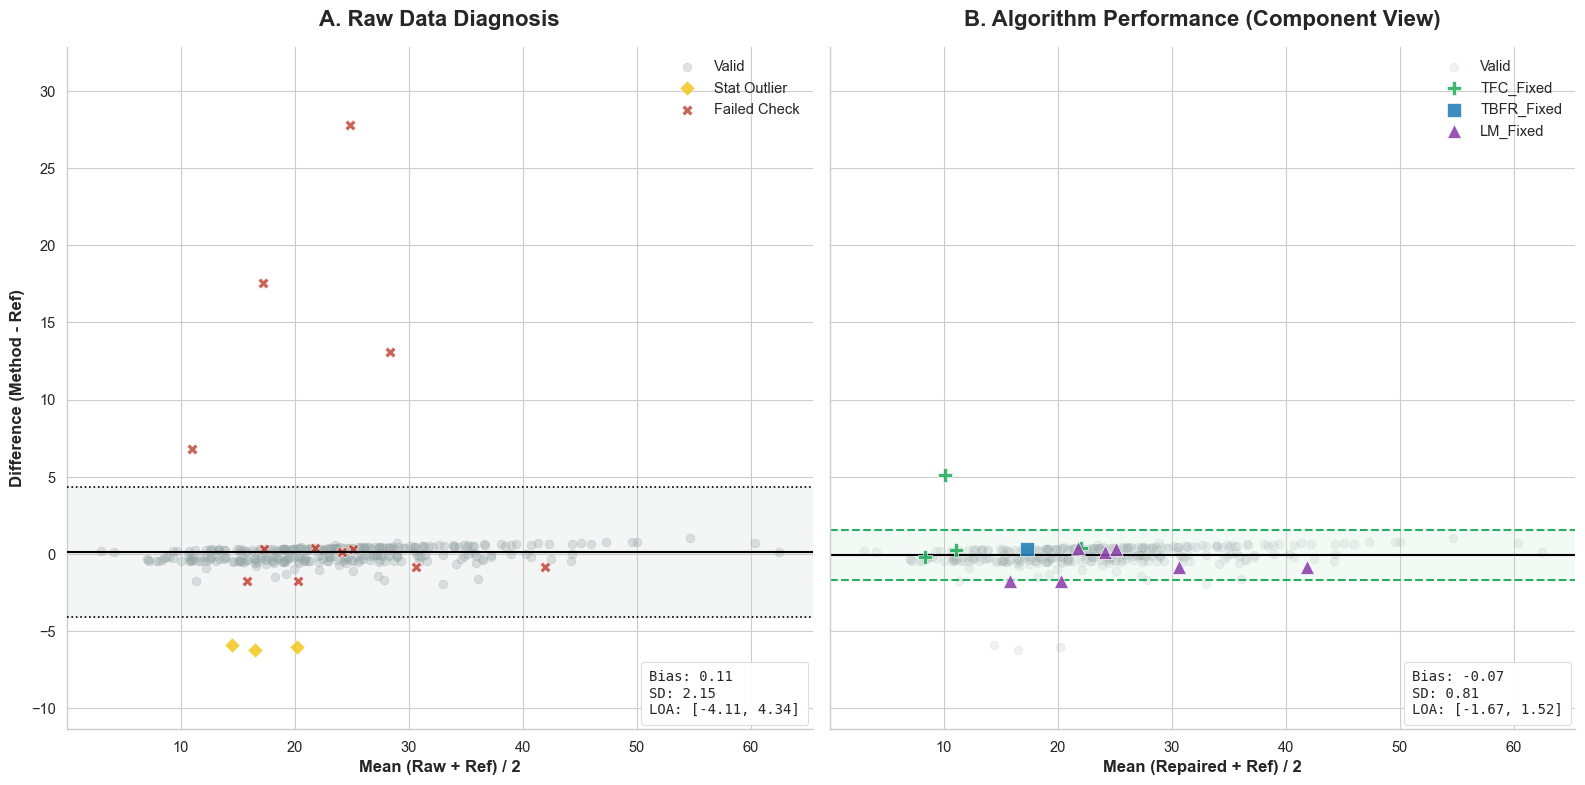

In [25]:
col_TFC_calc_4C_TBW_fixed = 'TFC_calc_4C_TBW_fixed'
df_bioimpedance[col_TFC_calc_4C_TBW_fixed] = df_bioimpedance['Weight'] - df_bioimpedance[col_TBW_fixed] - df_bioimpedance['Bone Mass (BM)'] - df_bioimpedance[col_TPC_calc_ratio] - epsilon_4C

col_TFC_mean_raw_TBW_fixed = 'TFC_mean_raw_TBW_fixed'
df_bioimpedance[col_TFC_mean_raw_TBW_fixed] = (df_bioimpedance['Total Fat Content (TFC)'] + df_bioimpedance[col_TFC_calc_4C_TBW_fixed]) / 2

col_TFC_diff_raw_TBW_fixed = 'TFC_diff_raw_TBW_fixed'
df_bioimpedance[col_TFC_diff_raw_TBW_fixed] = df_bioimpedance['Total Fat Content (TFC)'] - df_bioimpedance[col_TFC_calc_4C_TBW_fixed]

col_TFC_mean_fixed_TBW_fixed = 'TFC_mean_fixed_TBW_fixed'
df_bioimpedance[col_TFC_mean_fixed_TBW_fixed] = (df_bioimpedance[col_TFC_fixed] + df_bioimpedance[col_TFC_calc_4C_TBW_fixed]) / 2

col_TFC_diff_fixed_TBW_fixed = 'TFC_diff_fixed_TBW_fixed'
df_bioimpedance[col_TFC_diff_fixed_TBW_fixed] = df_bioimpedance[col_TFC_fixed] - df_bioimpedance[col_TFC_calc_4C_TBW_fixed]

_Bland_Altman_comparison(
    df_bioimpedance,
    col_TFC_mean_raw_TBW_fixed,
    col_TFC_diff_raw_TBW_fixed,
    col_TFC_mean_fixed_TBW_fixed,
    col_TFC_diff_fixed_TBW_fixed,
    col_TFC_fix_status,
    col_TBFR_fix_status,
    col_LM_fix_status,
    TFC_disc_fit_both_lim
)

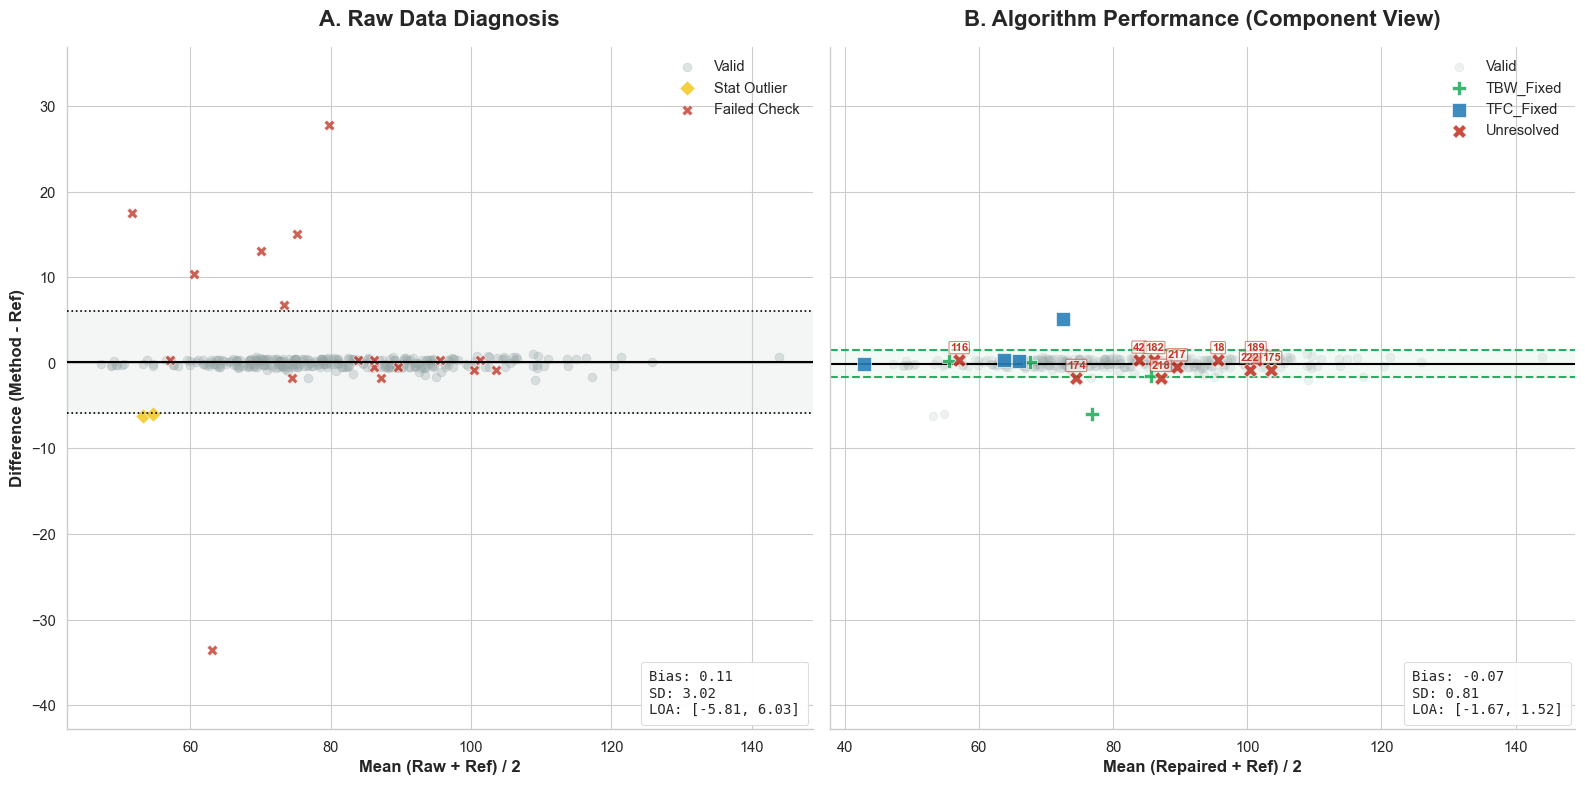

In [26]:
# ==========================================
# 1. Define the Sums (Method)
# ==========================================

# A. Original Sum (Raw TBW + Raw TFC + Constants)
col_Sum_Original = 'Sum_Components_Original'
df_bioimpedance[col_Sum_Original] = (
    df_bioimpedance['Total Body Water (TBW)'] +
    df_bioimpedance['Total Fat Content (TFC)'] +
    df_bioimpedance['Bone Mass (BM)'] +
    df_bioimpedance[col_TPC_calc_ratio] +
    epsilon_4C
)

# B. Fixed Sum (Fixed TBW + Fixed TFC + Constants)
col_Sum_Fixed = 'Sum_Components_Fixed'
df_bioimpedance[col_Sum_Fixed] = (
    df_bioimpedance[col_TBW_fixed] +
    df_bioimpedance[col_TFC_fixed] +
    df_bioimpedance['Bone Mass (BM)'] +
    df_bioimpedance[col_TPC_calc_ratio] +
    epsilon_4C
)

# ==========================================
# 2. Prepare Bland-Altman Vectors
# ==========================================

# --- Panel A: Raw Sum vs Weight ---
col_Mean_Raw_Weight = 'Mean_SumRaw_Weight'
# Mean = (Sum + Weight) / 2
df_bioimpedance[col_Mean_Raw_Weight] = (df_bioimpedance[col_Sum_Original] + df_bioimpedance['Weight']) / 2

col_Diff_Raw_Weight = 'Diff_SumRaw_Weight'
# Difference = Method (Sum) - Reference (Weight)
df_bioimpedance[col_Diff_Raw_Weight] = df_bioimpedance[col_Sum_Original] - df_bioimpedance['Weight']

# --- Panel B: Fixed Sum vs Weight ---
col_Mean_Fixed_Weight = 'Mean_SumFixed_Weight'
df_bioimpedance[col_Mean_Fixed_Weight] = (df_bioimpedance[col_Sum_Fixed] + df_bioimpedance['Weight']) / 2

col_Diff_Fixed_Weight = 'Diff_SumFixed_Weight'
df_bioimpedance[col_Diff_Fixed_Weight] = df_bioimpedance[col_Sum_Fixed] - df_bioimpedance['Weight']

col_dummy_fix = 'Dummy_False'
df_bioimpedance[col_dummy_fix] = False

# Execute your specific configuration
_Bland_Altman_comparison(
    df_bioimpedance,
    col_Mean_Raw_Weight,    # X-Axis (Raw)
    col_Diff_Raw_Weight,    # Y-Axis (Raw)
    col_Mean_Fixed_Weight,  # X-Axis (Fixed)
    col_Diff_Fixed_Weight,  # Y-Axis (Fixed)

    # --- MAPPING COLORS ---
    col_TBW_fix_status,     # Green: TBW corrected the sum
    col_TFC_fix_status,     # Blue:  TFC corrected the sum
    col_dummy_fix,          # Purple: (Unused)

    # --- LOGIC MASK ---
    # Gray = Both Water AND Fat were valid originally
    TBW_disc_fit_both_lim & TFC_disc_fit_both_lim
)

In [27]:
df_fixed = df.copy()
df_fixed

,Gallstone Status,Age,Gender,Comorbidity,Coronary Artery Disease (CAD),Hypothyroidism,Hyperlipidemia,Diabetes Mellitus (DM),Height,Weight,...,High Density Lipoprotein (HDL),Triglyceride,Aspartat Aminotransferaz (AST),Alanin Aminotransferaz (ALT),Alkaline Phosphatase (ALP),Creatinine,Glomerular Filtration Rate (GFR),C-Reactive Protein (CRP),Hemoglobin (HGB),Vitamin D
0,0,50,0,0,0,0,0,0,185,92.8,...,40.0,134.0,20.0,22.0,87.0,0.82,112.47,0.0,16.0,33.0
1,0,47,0,1,0,0,0,0,176,94.5,...,43.0,103.0,14.0,13.0,46.0,0.87,107.10,0.0,14.4,25.0
2,0,61,0,0,0,0,0,0,171,91.1,...,43.0,69.0,18.0,14.0,66.0,1.25,65.51,0.0,16.2,30.2
3,0,41,0,0,0,0,0,0,168,67.7,...,59.0,53.0,20.0,12.0,34.0,1.02,94.10,0.0,15.4,35.4
4,0,42,0,0,0,0,0,0,178,89.6,...,30.0,326.0,27.0,54.0,71.0,0.82,112.47,0.0,16.8,40.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
314,1,49,0,0,0,0,0,0,178,88.8,...,55.0,81.0,28.0,50.0,90.0,0.98,94.50,6.2,16.5,8.3
315,1,31,1,0,0,0,0,0,157,53.4,...,58.0,64.0,24.0,16.0,38.0,0.50,128.50,0.0,12.5,24.0
316,1,58,0,0,0,0,0,0,172,96.6,...,45.0,168.0,21.0,27.0,94.0,1.04,83.23,0.0,15.4,15.7
317,1,37,1,0,0,0,0,0,177,88.4,...,33.0,253.0,40.0,22.0,115.0,1.01,98.23,0.4,16.0,33.3


In [28]:
df_fixed['Total Body Water (TBW)'] = df_bioimpedance[col_TBW_fixed]
df_fixed['Intracellular Water (ICW)'] = df_bioimpedance[col_ICW_fixed]
df_fixed['Body Mass Index (BMI)'] = df_fixed['Weight']/((df_fixed['Height']/100)**2)
df_fixed['Total Fat Content (TFC)'] = df_bioimpedance['TFC_fixed']
df_fixed['Lean Mass (LM) (%)'] = df_bioimpedance['LM_fixed']
df_fixed['Total Body Fat Ratio (TBFR) (%)'] = df_bioimpedance['TBFR_fixed']
df_fixed['Obesity (%)'] = np.where(df_fixed['Obesity (%)'] == 1954, 19.54, df_fixed['Obesity (%)'])
df_fixed.to_csv('../../Storage/Storage.csv',index=False)